# Explainable Medical Recommendation System on the Precision Medicine Knowledge Graph

We want to make a hybrid Recommendation System that combines traditional RS methods and Knowledge Graphs.
We propose the idea that recommendations made on the basis of the graph structure can be explained by finding paths between the starting node and the recommended node.
Feeding both our recommendation and the paths found to a LLM trained on medical texts to summarize our finding, as well as make use of its medical knowledge, we hope to explain the reasoning of our system.

# 0. Environment and Dependencies

We establish our environment by importing needed packages.

In [ ]:
import pickle
from itertools import pairwise
from collections import Counter
from difflib import SequenceMatcher
from pathlib import Path

import Levenshtein
import lmstudio as lms
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# 1. Data Loading and Inspection

We import structured datasets tracking patient symptoms and prognosis (`Disease-Symptom Dataset`) alongside a biomedical knowledge graph infrastructure (`PrimeKG`).


## 1.1 Patients (Users)

In [63]:
users_df = pd.read_csv('data\\user_diseases_symptoms.csv')
print(users_df.info())
users_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 190672 entries, 0 to 190671
Columns: 655 entries, diseases to corneal damage
dtypes: int64(654), str(1)
memory usage: 955.7 MB
None


,diseases,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,continuous_sneezing,shivering,chills,watering_from_eyes,stomach_pain,...,coughing with mucus,loose tooth,excessive hunger,dry skin.1,swollen ankles,crippled,bleeding from the navel,muscle pain.1,itching.1,corneal damage
0,fungal infection,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,fungal infection,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,fungal infection,1,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,fungal infection,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,fungal infection,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Divide users in bins depending on the amount of symptoms they are indicating.

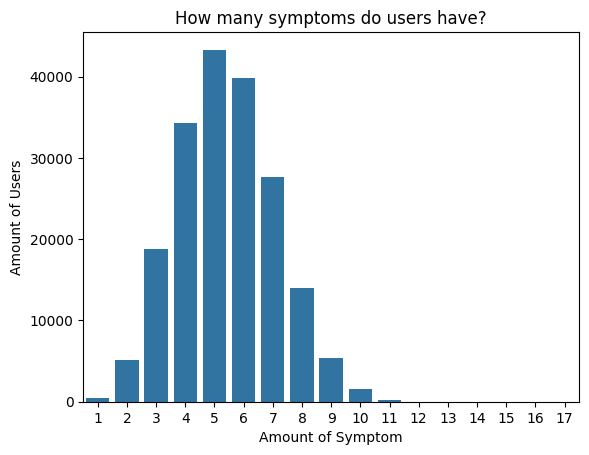

In [64]:
# Isolate symptom symptoms
symptom_cols = users_df.columns.drop('diseases')

# Aggregate non-zero symptoms vertically calculate the distribution per sample
symptoms_per_user = users_df[symptom_cols].sum(axis=1)

# Graph symptom bins and amount of users in them
sns.countplot(x=symptoms_per_user)
plt.title('How many symptoms do users have?')
plt.xlabel('Amount of Symptom')
plt.ylabel('Amount of Users')
plt.show()

## 1.2 Precision Medicine Knowledge Graph

"Precision Medicine Knowledge Graph (PrimeKG) presents a holistic view of diseases. PrimeKG integrates 20 high-quality biomedical resources to describe 17,080 diseases with 4,050,249 relationships representing ten major biological scales. We accompany PrimeKG’s graph structure with text descriptions of clinical guidelines for drugs and diseases to enable multimodal analyses."

In [ ]:
primekg = pd.read_csv('data\\kg.csv', usecols=['relation', 'x_index', 'x_type', 'x_name', 'y_index', 'y_type', 'y_name'], low_memory=False)
print(primekg.info())
primekg.head()

<class 'pandas.DataFrame'>
RangeIndex: 8100498 entries, 0 to 8100497
Data columns (total 7 columns):
 #   Column    Dtype
---  ------    -----
 0   relation  str  
 1   x_index   int64
 2   x_type    str  
 3   x_name    str  
 4   y_index   int64
 5   y_type    str  
 6   y_name    str  
dtypes: int64(2), str(5)
memory usage: 887.7 MB
None


,relation,x_index,x_type,x_name,y_index,y_type,y_name
0,protein_protein,0,gene/protein,PHYHIP,8889,gene/protein,KIF15
1,protein_protein,1,gene/protein,GPANK1,2798,gene/protein,PNMA1
2,protein_protein,2,gene/protein,ZRSR2,5646,gene/protein,TTC33
3,protein_protein,3,gene/protein,NRF1,11592,gene/protein,MAN1B1
4,protein_protein,4,gene/protein,PI4KA,2122,gene/protein,RGS20


<Axes: title={'center': 'Amount of edges of any given relation'}, xlabel='Amount (log scale)', ylabel='Relation'>

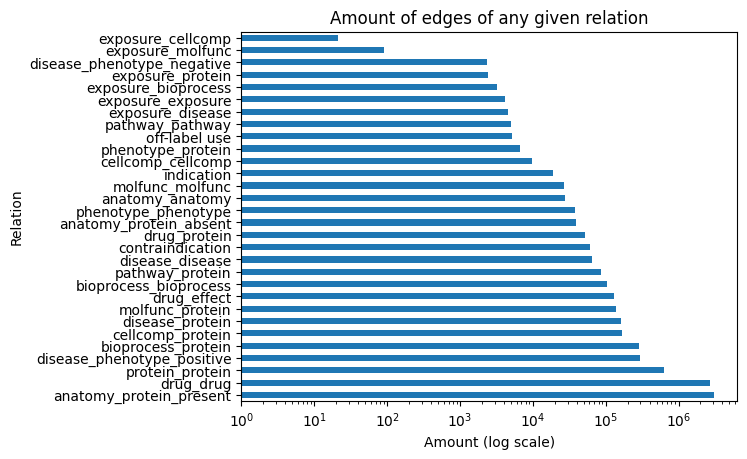

In [141]:
# 30 relation types in total
primekg['relation'].value_counts().plot(kind='barh',
                                        title='Amount of edges of any given relation',
                                        xlabel='Amount (log scale)',
                                        ylabel='Relation',
                                        log=True)

## 1.3 PrimeKG Structural Nodes

Next, we extract the metadata and classification attributes of the nodes defining our primary medical knowledge graph.

In [65]:
nodes_df = pd.read_csv('data\\nodes.csv', usecols=['node_index', 'node_type', 'node_name'], low_memory=False)
print(nodes_df.info())
nodes_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 129375 entries, 0 to 129374
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   node_index  129375 non-null  int64
 1   node_type   129375 non-null  str  
 2   node_name   129375 non-null  str  
dtypes: int64(1), str(2)
memory usage: 8.0 MB
None


,node_index,node_type,node_name
0,0,gene/protein,PHYHIP
1,1,gene/protein,GPANK1
2,2,gene/protein,ZRSR2
3,3,gene/protein,NRF1
4,4,gene/protein,PI4KA


<Axes: title={'center': 'Types of Nodes in PrimeKG'}, xlabel='Amount of nodes', ylabel='Node Type'>

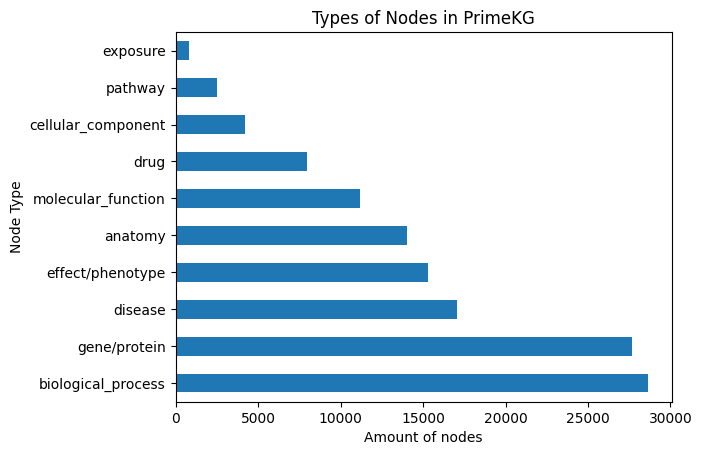

In [ ]:
# 10 types of nodes in total
nodes_df['node_type'].value_counts().plot(kind='barh',
                                          title='Types of Nodes in PrimeKG',
                                          xlabel='Amount of nodes',
                                          ylabel='Node Type')

# 2: Entity Resolution

Because our patient dataset and the knowledge graph come from independent medical classification structures, their lexicon and spelling variants diverge. This section implements standard mathematical string similarities to unify vocabulary tokens and resolve naming discrepancies.


## 2.0 Helper Methods and Preprocessing

In [69]:
RANDOM_SEED = 42

In [70]:
def similarity(s1, s2, alpha=0.5):
    # 1. Get the standard ratio (0.0 to 1.0)
    seq_ratio = SequenceMatcher(None, s1, s2).ratio()
    
    # 2. Get the Levenshtein distance
    lev_dist = Levenshtein.distance(s1, s2)
    
    # 3. Normalize and invert Levenshtein from [0, inf] to a [0, 1] similarity score
    max_len = max(len(s1), len(s2))
    if max_len == 0:
        lev_ratio = 1.0  # Both strings are empty
    else:
        # Distance divided by max_len gives a 0-1 error rate. 
        # Subtracting from 1.0 turns it into a 0-1 similarity score.
        lev_ratio = 1.0 - (lev_dist / max_len)
    
    # 4. Safely combine them using alpha
    return alpha * seq_ratio + (1 - alpha) * lev_ratio

def similarity_list(s1, ss):
    return [similarity(s1, s2) for s2 in ss]

Very simple examples and tests.

In [71]:
print(similarity('apple', 'apple'))                             # perfect match
print(similarity('abc', 'xyz'))                                 # no match
print(similarity('the quick brown fox', 'brown fox the quick')) # shifted
print(similarity('javascript', 'javascrip'))                    # typo
print(similarity('test', 'test elongated with extra words'))    # length distortion

1.0
0.0
0.26315789473684215
0.9236842105263158
0.17880184331797233


Lowercase and remove underscores for users symptoms and diseases.

We apply formatting masks across all user frames, disease label sequences, and knowledge graph records to construct uniform lower-case space-delimited target vectors.


In [72]:
columns_to_rename = {c: c.lower().replace('_', ' ') for c in users_df.columns}
users_df.rename(columns=columns_to_rename, inplace=True)

In [73]:
users_df['diseases'] = users_df['diseases'].apply(lambda x: x.lower().replace('_', ' '))

In [74]:
nodes_df['node_name'] = nodes_df['node_name'].apply(lambda x: x.lower().replace('_', ' '))

## 2.1 Mapping Similar Symptoms

In [75]:
selected_users_symptoms = set(users_df.columns)
print(len(selected_users_symptoms))
selected_users_symptoms

632


{'abdominal bloating',
 'abdominal distention',
 'abdominal pain',
 'abnormal appearing skin',
 'abnormal appearing tongue',
 'abnormal breathing sounds',
 'abnormal involuntary movements',
 'abnormal menstruation',
 'abnormal movement of eyelid',
 'abnormal size or shape of ear',
 'absence of menstruation',
 'abusing alcohol',
 'ache all over',
 'acidity',
 'acidity.1',
 'acne or pimples',
 'acute liver failure',
 'allergic reaction',
 'altered sensorium',
 'anal burning',
 'anal pain',
 'ankle pain',
 'ankle stiffness or tightness',
 'ankle swelling',
 'ankle weakness',
 'anorexia',
 'antisocial behavior',
 'anxiety',
 'anxiety and nervousness',
 'anxiety.1',
 'apnea',
 'arm cramps or spasms',
 'arm lump or mass',
 'arm pain',
 'arm stiffness or tightness',
 'arm swelling',
 'arm weakness',
 'back cramps or spasms',
 'back mass or lump',
 'back pain',
 'back pain.1',
 'back stiffness or tightness',
 'back swelling',
 'back weakness',
 'bedwetting',
 'belly pain',
 'blackheads',
 'bla

In [76]:
kg_symptoms = set(nodes_df[nodes_df['node_type'] == 'effect/phenotype']['node_name'])
print(len(kg_symptoms))
kg_symptoms

15311


{'discolored lateral incisors',
 'tritanomaly',
 'sleep-wake cycle disturbance',
 'abnormal alveolar macrophage morphology',
 'type 1 fibers relatively smaller than type 2 fibers',
 'abnormality of the tibial plateaux',
 'tessier number 4 facial cleft',
 'onychauxis',
 'stippling of the epiphysis of the middle phalanx of the 2nd finger',
 'scrotal pain',
 'irregular epiphysis of the middle phalanx of the 2nd toe',
 'abnormality of the ulna',
 'vivid hallucinations',
 'praxis-induced seizure',
 'focal impaired awareness seizure',
 'abnormal cerebral vein morphology',
 'intracranial neurenteric cyst',
 'eosinophilic gallbladder infiltration',
 'abnormality of the hepatic vasculature',
 'severe limb shortening',
 'focal manual automatism seizure',
 'few cafe-au-lait spots',
 'elevated urinary dicarboxylic acid level',
 'hyperapobetalipoproteinemia',
 'irregular epiphyses of the 2nd toe',
 'prominent calcaneus',
 'frontal cutaneous lipoma',
 'perioral eczema',
 'absent mastoid',
 'thin myo

Find out what symptoms the two datasets have in common.

In [77]:
common_symptoms = selected_users_symptoms & kg_symptoms
print(len(common_symptoms))
common_symptoms

71


{'abdominal distention',
 'abdominal pain',
 'anal pain',
 'ankle pain',
 'ankle swelling',
 'ankle weakness',
 'anorexia',
 'anxiety',
 'apnea',
 'back pain',
 'blindness',
 'bloody diarrhea',
 'blurred vision',
 'chest pain',
 'chest tightness',
 'chills',
 'coma',
 'cough',
 'dark urine',
 'dehydration',
 'dry skin',
 'ear pain',
 'elbow pain',
 'excessive salivation',
 'family history',
 'fatigue',
 'fever',
 'flatulence',
 'flushing',
 'gingivitis',
 'groin pain',
 'headache',
 'hemoptysis',
 'hip pain',
 'hoarse voice',
 'hot flashes',
 'inability to walk',
 'infertility',
 'irritability',
 'jaundice',
 'jaw pain',
 'jaw swelling',
 'joint swelling',
 'knee pain',
 'lethargy',
 'loss of consciousness',
 'low back pain',
 'lymphedema',
 'melena',
 'mood swings',
 'muscle weakness',
 'nausea',
 'neck pain',
 'pallor',
 'palpitations',
 'paralysis',
 'paresthesia',
 'peripheral edema',
 'polyuria',
 'restlessness',
 'shivering',
 'shoulder pain',
 'slurred speech',
 'stiff neck',
 '

Find out which symptoms users_df differ from PrimeKG.

In [78]:
diff_symptoms = selected_users_symptoms - common_symptoms - {'diseases'}
print(len(diff_symptoms))
diff_symptoms

560


{'abdominal bloating',
 'abnormal appearing skin',
 'abnormal appearing tongue',
 'abnormal breathing sounds',
 'abnormal involuntary movements',
 'abnormal menstruation',
 'abnormal movement of eyelid',
 'abnormal size or shape of ear',
 'absence of menstruation',
 'abusing alcohol',
 'ache all over',
 'acidity',
 'acidity.1',
 'acne or pimples',
 'acute liver failure',
 'allergic reaction',
 'altered sensorium',
 'anal burning',
 'ankle stiffness or tightness',
 'antisocial behavior',
 'anxiety and nervousness',
 'anxiety.1',
 'arm cramps or spasms',
 'arm lump or mass',
 'arm pain',
 'arm stiffness or tightness',
 'arm swelling',
 'arm weakness',
 'back cramps or spasms',
 'back mass or lump',
 'back pain.1',
 'back stiffness or tightness',
 'back swelling',
 'back weakness',
 'bedwetting',
 'belly pain',
 'blackheads',
 'bladder discomfort',
 'bladder insufficiency',
 'bladder mass',
 'bleeding from ear',
 'bleeding from eye',
 'bleeding from the navel',
 'bleeding gums',
 'bleedin

In [79]:
diff_symptoms = list(diff_symptoms)
kg_symptoms = list(kg_symptoms)

len(diff_symptoms), len(kg_symptoms)

(560, 15311)

In [80]:
symptom_similarity_path = Path("models\\similarity\\symptom_similarity_df.csv")

if symptom_similarity_path.is_file():
    symptom_similarity_df = pd.read_csv(symptom_similarity_path, index_col=0)
else:
    res = [similarity_list(ds, kg_symptoms) for ds in tqdm(diff_symptoms)]
    symptom_similarity_df = pd.DataFrame(data=res, index=diff_symptoms, columns=kg_symptoms)
    symptom_similarity_df.to_csv(symptom_similarity_path)

print(symptom_similarity_df.shape)
symptom_similarity_df.head()

(560, 15311)


,hemiatrophy of upper limb,anemia due to reduced life span of red cells,hypoxemia in cord blood,decreased cervical spine flexion due to contractures of posterior cervical muscles,triangular epiphysis of the distal phalanx of the 2nd finger,abnormality of hair growth rate,excessive salivation,csf pleocytosis,glomerular subendothelial widening,colonic arteriovenous malformation,...,anomalous splenoportal venous system,posterior scalloping of vertebral bodies,prominent stem of antihelix,glycogen accumulation in muscle fiber lysosomes,pancreatic fistula,normal density transverse bands in metaphyses of the upper limbs,hypertension associated with pheochromocytoma,aplasia of the inferior half of the cerebellar vermis,aplasia/hypoplasia of the biceps,abnormal cornea morphology
swelling of scrotum,0.301818,0.222403,0.253623,0.194277,0.188924,0.325161,0.203205,0.196594,0.190899,0.149001,...,0.238384,0.365890,0.244767,0.257898,0.214083,0.186559,0.251736,0.191562,0.250613,0.162821
itchy eyelid,0.376216,0.204545,0.229814,0.117151,0.155556,0.180795,0.225000,0.137037,0.218670,0.182225,...,0.104167,0.164423,0.264957,0.120988,0.155556,0.188734,0.143275,0.183164,0.230114,0.136640
dizziness.1,0.095556,0.118182,0.153453,0.117952,0.103756,0.103687,0.171774,0.143590,0.147712,0.147712,...,0.140662,0.128431,0.179337,0.150037,0.159004,0.148021,0.115873,0.115861,0.139898,0.092516
increased appetite,0.302791,0.247434,0.211559,0.215366,0.138462,0.251481,0.307895,0.116162,0.156109,0.266968,...,0.226852,0.173707,0.370370,0.166776,0.388889,0.227896,0.269841,0.164629,0.209375,0.274476
blisters,0.140606,0.152972,0.107994,0.120461,0.138235,0.208850,0.182143,0.230435,0.154062,0.231092,...,0.160354,0.179167,0.188360,0.136557,0.198718,0.138021,0.112159,0.122178,0.168750,0.194570


In [81]:
new_symptom_names = {}
used_symptoms = set(common_symptoms)

for old_symptom, similarity_series in symptom_similarity_df.iterrows():
    # Sort the similarities for the current old_symptom from highest to lowest
    sorted_matches = similarity_series.sort_values(ascending=False).index
    
    # Find the first best match that hasn't been used yet
    for best_match in sorted_matches:
        if best_match not in used_symptoms:
            used_symptoms.add(best_match)
            new_symptom_names[old_symptom] = best_match
            break
    else:
        # Fallback: If ALL possible matches are somehow taken, 
        # keep the original name so we don't lose the column.
        new_symptom_names[old_symptom] = old_symptom
        used_symptoms.add(old_symptom)

# Rename the DataFrame columns
users_df.rename(columns=new_symptom_names, inplace=True)

print(len(used_symptoms))
users_df.shape

631


(190672, 655)

## 2.2 Mapping Diseases

In [82]:
selected_users_diseases = set(users_df['diseases'])
print(len(selected_users_diseases))
selected_users_diseases

820


{'abdominal aortic aneurysm',
 'abdominal hernia',
 'abscess of nose',
 'abscess of the lung',
 'abscess of the pharynx',
 'acanthosis nigricans',
 'acariasis',
 'achalasia',
 'acne',
 'actinic keratosis',
 'acute bronchiolitis',
 'acute bronchitis',
 'acute bronchospasm',
 'acute glaucoma',
 'acute kidney injury',
 'acute otitis media',
 'acute pancreatitis',
 'acute sinusitis',
 'acute stress reaction',
 'adhd',
 'adhesive capsulitis of the shoulder',
 'adjustment reaction',
 'adrenal adenoma',
 'adrenal cancer',
 'aflp',
 'alcohol abuse',
 'alcohol intoxication',
 'alcohol withdrawal',
 'alcoholic hepatitis',
 'alcoholic liver disease',
 'allergy',
 'allergy to animals',
 'alopecia',
 'als',
 'alzheimer disease',
 'amblyopia',
 'amyloidosis',
 'anal fissure',
 'anal fistula',
 'anemia',
 'anemia due to chronic kidney disease',
 'anemia due to malignancy',
 'anemia of chronic disease',
 'angina',
 'ankylosing spondylitis',
 'anxiety',
 'aortic valve disease',
 'aphakia',
 'aphthous u

In [83]:
kg_diseases = set(nodes_df[nodes_df['node_type'] == 'disease']['node_name'])
print(len(kg_diseases))
kg_diseases

17079


{'vacterl/vater association',
 'demodicidosis',
 'microphthalmia with limb anomalies',
 'isolated encephalocele',
 'hyperthyroxinemia, familial dysalbuminemic',
 'hypomagnesemia, hypertension, and hypercholesterolemia, mitochondrial',
 'renal tubular dysgenesis',
 'hereditary chronic pancreatitis',
 "pituitary deficiency due to rathke's pouch cysts",
 'actinobacillus infectious disease',
 'carnitine palmitoyl transferase 1a deficiency',
 'pupil disease',
 'short limb dwarf lethal colavita kozlowski type',
 'corticosteroid-binding globulin deficiency',
 'trichotillomania',
 'benign mixed tumor of the vulva',
 'liver cancer',
 'progressive encephalomyelitis with rigidity and myoclonus',
 'signet ring cell variant cervical mucinous adenocarcinoma',
 'cutaneous anthrax',
 'neurodevelopmental disorder with seizures and brain atrophy',
 'aggressive b-cell non-hodgkin lymphoma',
 'biliary cystadenocarcinoma',
 'vaginal germ cell malignant tumor',
 'joubert syndrome with jeune asphyxiating tho

Find out which symptoms users_df and PrimeKG have in common.

In [84]:
common_diseases = selected_users_diseases & kg_diseases
print(len(common_diseases))
common_diseases

310


{'abdominal aortic aneurysm',
 'acute bronchiolitis',
 'acute otitis media',
 'alcohol withdrawal',
 'alcoholic hepatitis',
 'alopecia',
 'alzheimer disease',
 'ankylosing spondylitis',
 'anxiety',
 'aortic valve disease',
 'aplastic anemia',
 'appendicitis',
 'asperger syndrome',
 'aspergillosis',
 'asthma',
 'astigmatism',
 'avascular necrosis',
 'balanitis',
 'beriberi',
 'bipolar disorder',
 'blepharitis',
 'blepharospasm',
 'bone cancer',
 'brain cancer',
 'breast cancer',
 'breast cyst',
 'bronchitis',
 'burn',
 'bursitis',
 'cancer',
 'carcinoid syndrome',
 'cardiac arrest',
 'cardiomyopathy',
 'carpal tunnel syndrome',
 'cataract',
 'celiac disease',
 'cerebral palsy',
 'cervical cancer',
 'chalazion',
 'chickenpox',
 'chikungunya',
 'cholecystitis',
 'choledocholithiasis',
 'cholera',
 'chronic kidney disease',
 'chronic otitis media',
 'colorectal cancer',
 'common cold',
 'complex regional pain syndrome',
 'conduct disorder',
 'conjunctivitis',
 'contact dermatitis',
 'conve

Find out which diseases from users_df differ from PrimeKG.

In [85]:
diff_diseases = selected_users_diseases - common_diseases
print(len(diff_diseases))
diff_diseases

510


{'abdominal hernia',
 'abscess of nose',
 'abscess of the lung',
 'abscess of the pharynx',
 'acanthosis nigricans',
 'acariasis',
 'achalasia',
 'acne',
 'actinic keratosis',
 'acute bronchitis',
 'acute bronchospasm',
 'acute glaucoma',
 'acute kidney injury',
 'acute pancreatitis',
 'acute sinusitis',
 'acute stress reaction',
 'adhd',
 'adhesive capsulitis of the shoulder',
 'adjustment reaction',
 'adrenal adenoma',
 'adrenal cancer',
 'aflp',
 'alcohol abuse',
 'alcohol intoxication',
 'alcoholic liver disease',
 'allergy',
 'allergy to animals',
 'als',
 'amblyopia',
 'amyloidosis',
 'anal fissure',
 'anal fistula',
 'anemia',
 'anemia due to chronic kidney disease',
 'anemia due to malignancy',
 'anemia of chronic disease',
 'angina',
 'aphakia',
 'aphthous ulcer',
 'ards',
 'arrhythmia',
 'arthritis',
 'arthritis of the hip',
 'ascending cholangitis',
 'atelectasis',
 'athletes foot',
 'atonic bladder',
 'atrial fibrillation',
 'atrial flutter',
 'atrophic skin condition',
 'a

In [86]:
diff_diseases = list(diff_diseases)
kg_diseases = list(kg_diseases)

len(diff_diseases), len(kg_diseases)

(510, 17079)

In [87]:
diseases_similarity_path = Path("models\\similarity\\diseases_similarity_df.csv")

if diseases_similarity_path.is_file():
    diseases_similarity_df = pd.read_csv(diseases_similarity_path, index_col=0)
else:
    res = [similarity_list(ds, kg_diseases) for ds in tqdm(diff_diseases)]
    diseases_similarity_df = pd.DataFrame(data=res, index=diff_diseases, columns=kg_diseases)
    diseases_similarity_df.to_csv(diseases_similarity_path)

print(diseases_similarity_df.shape)
diseases_similarity_df.head()

(510, 17079)


,genetic peripheral neuropathy,nephrogenic diabetes insipidus-intracranial calcification syndrome,bartonellaceae infectious disease,inborn disorder of energy metabolism,paracoccidioidomycosis,"aniridia, microcornea, and spontaneously reabsorbed cataract",central nervous system calcification-deafness-tubular acidosis-anemia syndrome,non-syndromic diaphragmatic or thoracic malformation,autotopagnosia,undetermined colitis,...,dermis tumor,celiac trunk compression syndrome,obesity due to congenital leptin resistance,gallstones,pagon stephan syndrome,sternal neoplasm,"tibial torsion, bilateral medial",goldstein hutt syndrome,lipoma of the rectum,benign paroxysmal torticollis of infancy
oppositional disorder,0.223448,0.217346,0.306397,0.276316,0.184461,0.223457,0.247669,0.205743,0.290476,0.169570,...,0.186147,0.260943,0.303779,0.280338,0.299683,0.332046,0.298054,0.155138,0.217770,0.231148
poisoning due to antimicrobial drugs,0.223291,0.285651,0.184179,0.166667,0.214559,0.214583,0.181511,0.261364,0.257222,0.164683,...,0.208333,0.213164,0.354725,0.178140,0.280172,0.198718,0.228758,0.260593,0.240079,0.219737
urge incontinence,0.173163,0.231015,0.351515,0.158805,0.196387,0.213203,0.199123,0.154264,0.155598,0.262162,...,0.127789,0.261212,0.356202,0.265795,0.267483,0.180036,0.216199,0.258696,0.158108,0.205263
abscess of the lung,0.190374,0.181640,0.221445,0.288636,0.141353,0.129958,0.173606,0.227384,0.113238,0.076282,...,0.207980,0.259907,0.169167,0.216878,0.214523,0.162406,0.211397,0.206004,0.431410,0.240042
hypovolemia,0.118966,0.102814,0.166667,0.154551,0.181818,0.134507,0.123523,0.146673,0.302857,0.171774,...,0.172101,0.113636,0.211025,0.140693,0.189394,0.204861,0.155887,0.139386,0.261290,0.192647


In [88]:
new_diseases_names = {}
used_diseases = set(common_diseases)

for old_disease, similarity_series in diseases_similarity_df.iterrows():
    # Sort the similarities for the current old_disease from highest to lowest
    sorted_matches = similarity_series.sort_values(ascending=False).index
    
    # Find the first best match that hasn't been used yet
    for best_match in sorted_matches:
        if best_match not in used_diseases:
            used_diseases.add(best_match)
            new_diseases_names[old_disease] = best_match
            break
    else:
        # Fallback: If ALL possible matches are somehow taken, 
        # keep the original name so we don't lose the diseases.
        new_diseases_names[old_disease] = old_disease
        used_diseases.add(old_disease)

# Rename the DataFrame columns
users_df['diseases'] = users_df['diseases'].replace(new_diseases_names)

print(len(used_diseases))
users_df['diseases'].value_counts()

820


diseases
pneumonia                            1237
hypoglycemia                         1231
cystitis                             1219
vulvodynia                           1218
speech disorder                      1218
                                     ... 
rheumatic fever                         1
rocky mountain spotted fever            1
lichen planus                           1
fibroepithelial polyp of the anus       1
kaposi sarcoma                          1
Name: count, Length: 820, dtype: int64

## 2.3 Selecting Users for Downstream Tasks

Later down the line we will need unique ids for graph nodes. By remembering the largest index amongst all nodes, we can easily give users such ids.

In [89]:
nodes_index_max = int(nodes_df['node_index'].max())
nodes_index_max

129374


To optimize training performance, we downsample the user space to focus on the top $K=100$ most prevalent conditions, while cleaning dead features from our dimensions.

In [90]:
top_k_diseases = users_df['diseases'].value_counts().nlargest(100).index

diseases_with_most_users_df = users_df[users_df['diseases'].isin(top_k_diseases)]

selected_users_df = diseases_with_most_users_df.groupby('diseases').sample(n=100, random_state=RANDOM_SEED)
selected_users_df.reset_index(drop=True, inplace=True)
selected_users_df = pd.concat([pd.DataFrame([int(nodes_index_max + i + 1) for i in range(len(selected_users_df))], columns=['user_index']), selected_users_df], axis=1)

print(selected_users_df.info())
selected_users_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 656 entries, user_index to corneal arcus
dtypes: int64(655), str(1)
memory usage: 50.2 MB
None


,user_index,diseases,pointed chin,skin tags,unusual skin infection,achromatic retinal patches,contiguous gene syndrome,shivering,chills,arterial thrombosis,...,chin myoclonus,long foot,excessive cerumen,dry hair,stiff ankle,crumpled ear,bowing of the legs,muscle spasm,distichiasis,corneal arcus
0,129375,acquired keratosis,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,129376,acquired keratosis,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,129377,acquired keratosis,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,129378,acquired keratosis,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,129379,acquired keratosis,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Features showing zero occurrences across the patient sample don't provide useful context for training models. We remove them from our data space.

In [91]:
# 1. Drop columns with no present symptoms (all zeros)
selected_users_df = selected_users_df.loc[:, (selected_users_df != 0).any(axis=0)]

# 2. Drop duplicate columns
selected_users_df = selected_users_df.loc[:, ~selected_users_df.columns.duplicated()]

# 3. Drop
selected_users_df.drop_duplicates(inplace=True)
selected_users_df.reset_index(drop=True, inplace=True)
selected_users_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 295 entries, user_index to distichiasis
dtypes: int64(294), str(1)
memory usage: 22.7 MB


<Axes: title={'center': 'Amount of Symptoms Amongst Selected Users'}, xlabel='Symptom per user', ylabel='Users with Given Amount of Symptoms'>

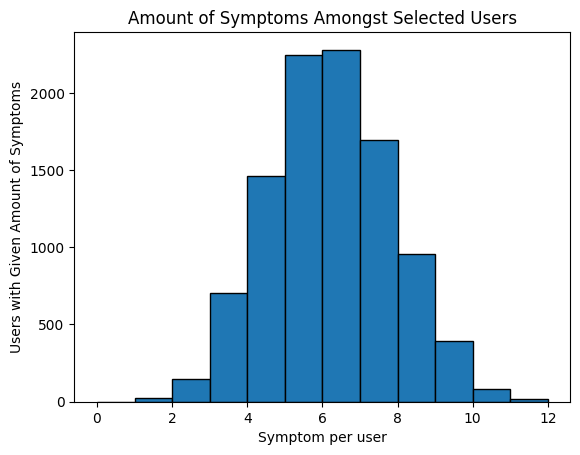

In [92]:
symptom_counts_row = selected_users_df.iloc[:, 2:].sum(axis=1)
symptom_counts_row.plot(kind='hist',
                        title='Amount of Symptoms Amongst Selected Users',
                        xlabel='Symptom per user',
                        ylabel='Users with Given Amount of Symptoms',
                        bins=12,
                        edgecolor='black',
                        range=[0, 12])

# 3. Building our Graph

This phase constructs a highly detailed semantic network from PrimeKG to connect clinical records with biochemical structures, patients with their symptoms and disease.

## 3.1 Prime Knowledge Graph

From the kg.csv file we build a NetworkX Graph.

In [93]:
# 1. Initialize path to save/load graph.
graph_path = Path("models\\graphs\\prime_kg_graph_big.pkl")

if graph_path.is_file():
    # 2. If file exists, load from file.
    with open(graph_path, 'rb') as f:
        G = pickle.load(f)
else:
    # 3. Otherwise build graph from PrimeKG.
    G = nx.Graph()

    # 4. Add nodes, edges and attributes in one pass
    for _, row in tqdm(primekg.iterrows(), total=len(primekg), desc='PrimeKG'):
        # Get source (u) and target (v) node IDs
        u = row['x_index']
        v = row['y_index']
        
        # Add u and v with their type and semantic name as attributes
        G.add_node(u, type=row['x_type'], name=row['x_name'])
        G.add_node(v, type=row['y_type'], name=row['y_name'])
        
        # Add edge with its relation type attribute
        G.add_edge(u, v, relation=row['relation'], type='neutral')

    # 5. Save to file
    with open(graph_path, 'wb') as f:
        pickle.dump(G, f)

print(f"Graph loaded successfully!")
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}, Edge density: {nx.density(G)*100:.4f}%")

Graph loaded successfully!
Total Nodes: 129375
Total Edges: 4049642, Edge density: 0.0484%


Select only the disease nodes from G who match diseases from selected_users.

In [94]:
def is_from_selected_users(data):
    # node is part of subgraph if its type is in the allowed subgraph_types
    # and if its type is a disease its in the selected_users diseases
    # and of ots type is effect/phenotype its in  the selected_users symptoms
    if (data['type'] not in {'disease', 'effect/phenotype'}):
        return False

    if (data['type'] == 'disease'):
        return data['name'].lower().replace('_', ' ') in selected_users_diseases

    if (data['type'] == 'effect/phenotype'):
        return data['name'].lower().replace('_', ' ') in selected_users_symptoms

    return False

selected_users_diseases = set(selected_users_df['diseases'])
selected_users_symptoms = set(selected_users_df.columns) - {'diseases', 'user_index'}

node_by_name = {data['name'].lower().replace('_', ' '): node
                for node, data in G.nodes(data=True)
                if is_from_selected_users(data) is True}

len(node_by_name) # disease and symptoms nodes

393

We split our selected user entries into independent training and testing subsets ($80/20$ split ratio).


In [95]:
selected_users_train_df, selected_users_test_df = train_test_split(selected_users_df, test_size=0.2, random_state=RANDOM_SEED)
selected_users_train_df.shape, selected_users_test_df.shape

((8000, 295), (2000, 295))

Add the selected train users to graph

In [96]:
for _, row in tqdm(selected_users_train_df.iterrows(), total=len(selected_users_train_df), desc='Train Users'):
    # Add user node
    user_index = row['user_index']
    user_disease = row['diseases']
    G.add_node(user_index, type='user', name=user_disease)
    
    # Get disease index; should already be in G
    diseases_index = node_by_name[user_disease]
    G.add_edge(user_index, diseases_index, relation='has_disease', type='train')
    
    # Add edges between user_node and symptom_node
    # .iloc[2:] skips 'user_index' and 'diseases'
    for symptom_name, indication in row.iloc[2:].items():
        if (indication == 1):
            symptom_index = node_by_name[symptom_name]
            G.add_edge(user_index, symptom_index, relation='has_phenotype', type='neutral')

Train Users: 100%|██████████| 8000/8000 [00:05<00:00, 1570.18it/s]


Add selected test users to graph

In [97]:
for _, row in tqdm(selected_users_test_df.iterrows(), total=len(selected_users_test_df), desc='Train Users'):
    # Add user node
    user_index = row['user_index']
    user_disease = row['diseases']
    G.add_node(user_index, type='user', name=user_disease)
    
    # Get disease index; should already be in G
    diseases_index = node_by_name[user_disease]
    G.add_edge(user_index, diseases_index, relation='has_disease', type='test')
    
    # Add edges between user_node and symptom_node
    # .iloc[2:] skips 'user_index' and 'diseases'
    for symptom_name, indication in row.iloc[2:].items():
        if (indication == 1):
            symptom_index = node_by_name[symptom_name]
            G.add_edge(user_index, symptom_index, relation='has_phenotype', type='neutral')

Train Users: 100%|██████████| 2000/2000 [00:01<00:00, 1564.88it/s]


In [98]:
print(f"\nAdded {len(selected_users_df)} users successfully!")
print(f"Total Nodes: {G.number_of_nodes()}")
print(f"Total Edges: {G.number_of_edges()}, Density: {nx.density(G)*100:.4f}%")


Added 10000 users successfully!
Total Nodes: 139375
Total Edges: 4116856, Density: 0.0424%


### Reduce Full Graph to Subgraph

We reduce our expressiveness to make training models easier.

To reduce computational overhead from unrelated sections of the knowledge graph, we isolate a dense semantic subgraph $H$ centered exclusively on classes like `disease`, `effect/phenotype`, `drug`, and `user`.

On top of that we only include `diseases` and `effects/phenotypes` found amongst the selected users.

In [99]:
def is_part_of_subgraph(data):
    # node is part of subgraph if its type is in the allowed subgraph_types
    # and if its type is a disease its in the selected_users diseases
    # and of ots type is effect/phenotype its in  the selected_users symptoms
    if (data['type'] not in subgraph_node_types):
        return False

    if (data['type'] == 'disease'):
        return data['name'].lower().replace('_', ' ') in selected_users_diseases

    if (data['type'] == 'effect/phenotype'):
        return data['name'].lower().replace('_', ' ') in selected_users_symptoms

    return True

# 1. Select types of nodes to keep.
subgraph_node_types = {'disease', 'effect/phenotype', 'drug', 'user'}
selected_users_symptoms = set(selected_users_df.columns)

# 2. Keep only nodes with selected types.
subgraph_nodes = [node for node, data in G.nodes(data=True) if is_part_of_subgraph(data) is True]

# 3. Induce subgraph H.
H = G.subgraph(subgraph_nodes).copy()

In [100]:
# 4. Relabel graph nodes to int to unify their type
H = nx.relabel_nodes(H, int)

In [101]:
# Delete big graph G to free up some memory.
del G

In [102]:
print(f"Subgraph induced successfully!")
print(f"Total Nodes: {H.number_of_nodes()}")
print(f"Total Edges: {H.number_of_edges()}, Density: {nx.density(H)*100:.4f}%")

Subgraph induced successfully!
Total Nodes: 18350
Total Edges: 1418133, Density: 0.8424%


In [103]:
node_types = []

for corpus_node, data in H.nodes(data=True):
    node_types.append(data['type'])

c = Counter(node_types)
c.most_common()

[('user', 10000), ('drug', 7957), ('effect/phenotype', 293), ('disease', 100)]

In [104]:
isolated_nodes = list(nx.isolates(H))
H.remove_nodes_from(isolated_nodes)

print(f"Subgraph induced successfully!")
print(f"Total Nodes: {H.number_of_nodes()}")
print(f"Total Edges: {H.number_of_edges()}, Density: {nx.density(H)*100:.4f}%")

Subgraph induced successfully!
Total Nodes: 14765
Total Edges: 1418133, Density: 1.3011%


In [105]:
node_types = []

for corpus_node, data in H.nodes(data=True):
    node_types.append(data['type'])

c = Counter(node_types)
c.most_common()

[('user', 10000), ('drug', 4372), ('effect/phenotype', 293), ('disease', 100)]

## 3.2 Random Walks

### Random Walk Sampling Strategy

To transform our graph into sequential paths suitable for Word2Vec modeling, we implement random walk sequences. We hide test label associations during walk generation to prevent data leakage.

We implement the standard DeepWalk sampling strategy where the next node in the walks in chosen uniformly amongst the neighbors.

We define a method that generates random walks in a graph:

path: node - node - ... - node

In [106]:
def random_walk(G, start_node, walk_length, ignore_test_labels, rng):
    # Initialize the walk with the starting node
    walk = [start_node]
    current_node = start_node
    
    for _ in range(walk_length):
        # Get neighbors of cur_node
        edges = list(G.edges(current_node, data=True))
        
        # If ignore_test_labels is True, filter out edges where type is 'test'
        if ignore_test_labels is True:
            edges = [e for e in edges if e[2]['type'] != 'test']

        # Dead-end check
        if not edges:
            break

        # Randomly choose the next edge
        chosen_edge_idx = rng.choice(len(edges))
        chosen_edge = edges[chosen_edge_idx]
        
        # chosen_edge is (current_node, neighbor_node, edge_attributes_dict)
        next_node = chosen_edge[1]
        walk.append(next_node)
        current_node = next_node
        
    return walk

We define a method that generates random walks in a graph:

path: node - edge - node - edge - ... - edge  - node

In [107]:
def random_walk_with_edges(G, start_node, walk_length, ignore_test_labels, rng):
    # Produces a walk of length: 2 * floor(walk_length / 2) + 1
    # Initialize the walk. We store the starting node and a placeholder/None for the initial incoming edge.
    # Format: (node, edge_data)
    walk = [start_node]
    current_node = start_node
    
    for _ in range(walk_length // 2):
        # Get neighbors of cur_node
        edges = list(G.edges(current_node, data=True))
        
        # If ignore_test_labels is True, filter out edges where type is 'test'
        if ignore_test_labels is True:
            edges = [e for e in edges if e[2]['type'] != 'test']

        # Dead-end check
        if not edges:
            break

        # Randomly choose the next edge
        chosen_edge_idx = rng.choice(len(edges))
        chosen_edge = edges[chosen_edge_idx]
        
        # chosen_edge is (current_node, neighbor_node, edge_attributes_dict)
        next_node = chosen_edge[1]
        edge_data = chosen_edge[2]['relation']

        walk.append(edge_data)
        walk.append(next_node)
        
        current_node = next_node
        
    return walk

The next method is a wrapper than makes calling previous walks easier.

In [108]:
def generate_random_walks(G, source_nodes=None, walks_per_node=10, walk_length=80, edges=False, ignore_test_labels=True, seed=42):
    rng = np.random.default_rng(seed=seed)
    if source_nodes is None:
        source_nodes = G.nodes()
    
    if (edges is True):
        return pd.DataFrame(random_walk_with_edges(G, n, walk_length, ignore_test_labels, rng)
                            for n in tqdm(source_nodes, desc='Nodes')
                            for _ in range(walks_per_node))
    else:
        return pd.DataFrame(random_walk(G, n, walk_length, ignore_test_labels, rng)
                            for n in tqdm(source_nodes, desc='Nodes')
                            for _ in range(walks_per_node))

We generate random walks for the train set of users.

In [109]:
random_walks_train_path = Path('models\\walks\\random_walks_train_drug_per_node_10_len_161_edges_1.csv')
source_nodes = selected_users_train_df['user_index'].to_list()

if random_walks_train_path.is_file():
    random_walks_train = pd.read_csv(random_walks_train_path, index_col=0, low_memory=False)
else:
    random_walks_train = generate_random_walks(H, source_nodes=source_nodes, walks_per_node=10, walk_length=160, edges=True, seed=RANDOM_SEED)
    random_walks_train.to_csv(random_walks_train_path)

random_walks_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Columns: 161 entries, 0 to 160
dtypes: int64(81), str(80)
memory usage: 163.1 MB


In [110]:
random_walks_train.head(1)

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
0,138629,has_disease,36368,has_disease,138655,has_phenotype,89892,has_phenotype,138627,has_phenotype,...,drug_drug,21055,drug_drug,18770,drug_drug,17585,drug_drug,15511,drug_drug,15377


We generate random walks for the test set of users.

In [111]:
random_walks_test_path = Path('models\\walks\\random_walks_test_drug_per_node_10_len_161_edges_1.csv')
source_nodes = selected_users_test_df['user_index'].to_list()

if random_walks_test_path.is_file():
    random_walks_test = pd.read_csv(random_walks_test_path, index_col=0, low_memory=False)
else:
    random_walks_test = generate_random_walks(H, source_nodes=source_nodes, walks_per_node=10, walk_length=160, edges=True, seed=RANDOM_SEED)
    random_walks_test.to_csv(random_walks_test_path)

random_walks_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 161 entries, 0 to 160
dtypes: int64(81), str(80)
memory usage: 40.8 MB


In [112]:
random_walks_test.head()

,0,1,2,3,4,5,6,7,8,9,...,151,152,153,154,155,156,157,158,159,160
0,135627,has_phenotype,25620,drug_effect,15434,drug_drug,20932,drug_drug,15162,drug_drug,...,drug_drug,15856,drug_drug,15133,drug_drug,14902,drug_drug,20787,drug_drug,17345
1,135627,has_phenotype,85606,has_phenotype,135619,has_phenotype,25620,drug_effect,15778,drug_drug,...,drug_drug,15873,drug_drug,14231,drug_drug,14387,drug_drug,15430,drug_drug,21010
2,135627,has_phenotype,85606,has_phenotype,135643,has_phenotype,23002,has_phenotype,138591,has_phenotype,...,has_phenotype,139372,has_phenotype,23469,has_phenotype,137184,has_phenotype,84409,drug_effect,14706
3,135627,has_phenotype,25620,drug_effect,14810,drug_drug,14216,drug_drug,14992,drug_drug,...,drug_drug,15401,drug_drug,17944,drug_drug,16590,drug_drug,20780,drug_drug,20564
4,135627,has_phenotype,23096,has_phenotype,133630,has_phenotype,91808,has_phenotype,136223,has_phenotype,...,has_phenotype,139057,has_disease,36523,has_disease,138993,has_phenotype,90038,has_phenotype,134831


### Formatting for Word2Vec Input Streams

We transform the random walks into a format suitable for Word2Vec.

In [113]:
temp = []
for _, row in tqdm(random_walks_train.iterrows(), total=len(random_walks_train)):
    temp.append(row.apply(str).to_list())
random_walks_train = temp

len(random_walks_train), len(random_walks_train[0])

100%|██████████| 80000/80000 [00:20<00:00, 3950.09it/s]


(80000, 161)

In [114]:
temp = []
for _, row in tqdm(random_walks_test.iterrows(), total=len(random_walks_test)):
    temp.append(row.apply(str).to_list())
random_walks_test = temp

len(random_walks_test), len(random_walks_test[0])

100%|██████████| 20000/20000 [00:04<00:00, 4196.71it/s]


(20000, 161)

## 3.3 Node2Vec (word2vec) Model

We emulate the Node2Vec model by training a Word2Vec model on the generated random walks.

In [115]:
def load_word2vec_model(model_path, train_set=None, **kwargs):
    if model_path.is_file():
        with open(model_path, 'rb') as f:
            word2vec_model = pickle.load(f)
    else:
        word2vec_model = Word2Vec(train_set, kwargs)
        with open(model_path, 'wb') as f:
            pickle.dump(word2vec_model, f)

    print(word2vec_model.get_latest_training_loss())
    return word2vec_model

Train on the `random_walks_train` sentences (load from disk).

The model is trained using CBOW and no hierarchical softmax.

In [116]:
word2vec_model_path = Path('models\\embedd\\word_2_vec_embeddings.pkl')
word2vec_model = load_word2vec_model(word2vec_model_path,
                                    train_set=random_walks_train,
                                    vector_size=128,
                                    window=10,
                                    min_count=5,
                                    sg=0,
                                    hs=0,
                                    negative=20,
                                    epochs=15,
                                    compute_loss=True,
                                    workers=4)

17915394.0


# 4: Local LLM Integration & Explainable AI Pathways

## 4.0 Helper Methods for Path Finding

We define some methods to help us find the shortest path between two nodes and get more information about them as to pass it to the LLM.

In [117]:
def get_k_shortest_paths(source, target, k=3):
    paths = []
    gen = nx.shortest_simple_paths(H, source, target)

    for _ in range(k):
        p = next(gen)
        paths.append(p)

    return paths

In [137]:
example_path = get_k_shortest_paths(131072, 131073, k=1)[0]
example_path

[131072, 28831, 131073]

In [118]:
# Translated a path of node ids to their corresponding node information.
def translate_path(path):
    tr_path = []

    for a, b in pairwise(path):
        tr_path.append(H.nodes[a])
        tr_path.append(H.get_edge_data(a, b))
    tr_path.append(H.nodes[b])

    return tr_path

In [138]:
tr_example_path = translate_path(example_path)
tr_example_path

[{'type': 'user', 'name': 'carpal tunnel syndrome'},
 {'relation': 'has_disease', 'type': 'train'},
 {'type': 'disease', 'name': 'carpal tunnel syndrome'},
 {'relation': 'has_disease', 'type': 'train'},
 {'type': 'user', 'name': 'carpal tunnel syndrome'}]

In [119]:
# Formulates path to be more 'human readable'.
def formulate_tr_path(path):
    sent = []

    is_node = True
    user_id = 0
    for data in path:
        if is_node: # node
            if (data['type'] == 'user'):
                sent.append(data['type'] + str(user_id))
                user_id += 1
            else:
                sent.append(data['name'])
        else: # edge
            sent.append(data['relation'])
        
        sent.append('->')
        is_node = not(is_node)

    return ' '.join(sent[:-1]) # remove last ->

In [139]:
formulate_tr_path(tr_example_path)

'user0 -> has_disease -> carpal tunnel syndrome -> has_disease -> user1'

## 4.1 Recommendation Example for Random Patients

We sample at random two users from `selected_users_test_df` and get their top 10 most similar nodes in graph. We will use the path finding methods from above to get 5 shortest paths for each and pass it to the LLM for explanation.

In [120]:
model_wv = word2vec_model.wv
test_df = selected_users_test_df
train_indexes = set(selected_users_train_df['user_index'])
rng = np.random.default_rng(RANDOM_SEED)

u1, u2 = rng.choice(test_df, size=2)
# print(u1)

u1_similar = model_wv.most_similar(str(u1[0]), topn=10)
u2_similar = model_wv.most_similar(str(u2[0]), topn=10)
# print(u1_similar)

u1_predicted = [H.nodes[int(sim)] for sim, _ in u1_similar]
u2_predicted = [H.nodes[int(sim)] for sim, _ in u2_similar]
# print(u1_predicted)

y1 = [u1[1] == data['name'] for data in u1_predicted]
y2 = [u2[1] == data['name'] for data in u2_predicted]

print("Amount of accurately recommended similar users:")
print("For y1:", sum(y1))
print("For y2:", sum(y2))

Amount of accurately recommended similar users:
For y1: 10
For y2: 10


In [121]:
# make to int for graph H
path_candidates_u1 = [int(x[0]) for x in u1_similar]
path_candidates_u2 = [int(x[0]) for x in u2_similar]

In [122]:
paths_u1 = []
for cand in path_candidates_u1:
    ps = get_k_shortest_paths(u1[0], cand, 5)
    paths_u1.extend(ps)
paths_u1 = [formulate_tr_path(translate_path(p)) for p in paths_u1]

paths_u2 = []
for cand in path_candidates_u2:
    ps = get_k_shortest_paths(u2[0], cand, 5)
    paths_u2.extend(ps)
paths_u2 = [formulate_tr_path(translate_path(p)) for p in paths_u2]

paths_u1[:5]

['user0 -> has_disease -> hearing disorder -> has_disease -> user1',
 'user0 -> has_phenotype -> Nasal chondritis -> has_phenotype -> user1',
 'user0 -> has_phenotype -> Ear pain -> has_phenotype -> user1',
 'user0 -> has_phenotype -> Prolonged bleeding time -> has_phenotype -> user1',
 'user0 -> has_disease -> hearing disorder -> has_disease -> user1 -> has_phenotype -> Nasal chondritis -> has_phenotype -> user2']

## 4.2 Local Model with LM Studio

We use a local LLM hosted on LM Studio called `TheBloke/meditron-7B-chat-GGUF`, version `Q3-K-M; 3.30GB`. It is a model specifically trained on medical texts.

>meditron-7b-chat is a finetuned version of epfl-llm/meditron-7b using SFT Training on the Alpaca Dataset.
> This model can answer >information about different excplicit ideas in medicine (see epfl-llm/meditron-7b for more info)

In [236]:
model = lms.llm("meditron-7b-chat")

In [ ]:
max_tokens = 250

def chat(history):
    prediction_stream = model.respond_stream(
        history=history,
        config={
            "temperature": 0.3,
            "maxTokens": max_tokens,
            "cpuThreads": 2,
        }
    )

    br = 0
    for fragment in prediction_stream:
        if (br % (max_tokens // 10) == 0):
            print()
        print(fragment.content, end="", flush=True)
        br += 1

In [249]:
history1 = f"We have a patient with a diagnosis of '{u1[1]}'. We have paths from this patient to others similar to them. Explain why the diagnosis is likely correct based on medical reasoning and on these paths: {'; '.join(paths_u1)}"
len(history1)

4429

In [ ]:
chat(history1)

# The diagnosis is likely correct because the paths from patient to others with similar
#  conditions all include a disease that is consistent with the patient's symptoms
# . The paths also show that the patient's condition can be explained by
#  multiple possible causes, including genetic factors and environmental exposures. Additionally,
#  the patient has phenotypes associated with hearing disorders, such as ear
#  pain and prolonged bleeding time, which are consistent with their diagnosis
# . However, it is important to note that a definitive diagnosis would
#  require further testing and evaluation by a medical professional. Overall, while this
#  analysis does not provide a definitive diagnosis, it can be used to
#  support the patient's symptoms and help guide further investigation. It is
#  also possible for the patient to have more than one condition or cause of their
#  hearing disorder. Therefore, a thorough examination by a medical professional is
#  still necessary.

# Диагнозата вероятно е правилна, защото пътищата от пациента към други с подобни състояния включват заболяване,
# което е съвместимо със симптомите на пациента. Пътищата показват също, че състоянието на пациента може да се
# обясни с множество възможни причини, включително генетични фактори и въздействие от околната среда. Освен това,
# пациентът има симптоми, свързани със слухови нарушения, като например болка в ухото и удължено време на кървене,
# които са съвместими с диагнозата му.

# Важно е обаче да се отбележи, че окончателната диагноза би изисквала допълнителни изследвания и оценка от медицински
# специалист. Като цяло, макар този анализ да не предоставя окончателна диагноза, той може да се използва за подкрепа
# на симптомите на пациента и да помогне за насочване на по-нататъшни изследвания. Възможно е също така пациентът да
# има повече от едно състояние или причина за слуховото си нарушение. Следователно, все още е необходим обстоен преглед
# от медицински специалист.


The diagnosis is likely correct because the paths from patient to others with similar
 conditions all include a disease that is consistent with the patient's symptoms
. The paths also show that the patient's condition can be explained by
 multiple possible causes, including genetic factors and environmental exposures. Additionally,
 the patient has phenotypes associated with hearing disorders, such as ear
 pain and prolonged bleeding time, which are consistent with their diagnosis
. However, it is important to note that a definitive diagnosis would
 require further testing and evaluation by a medical professional. Overall, while this
 analysis does not provide a definitive diagnosis, it can be used to
 support the patient's symptoms and help guide further investigation. It is
 also possible for the patient to have more than one condition or cause of their
 hearing disorder. Therefore, a thorough examination by a medical professional is
 still necessary.

### Explanation:
The paths fro

In [ ]:
history2 = f"We have a patient with a diagnosis of '{u2[1]}'. We have paths from this patient to others similar to them. Explain why the diagnosis is likely correct based on medical reasoning and these paths: {'; '.join(paths_u2)}"
len(history2)

"We have a patient with a diagnosis of 'macular degeneration'. We have paths from this patient to others similar to them. Explain why the diagnosis is likely correct based on medical reasoning and these paths: user0 -> has_disease -> macular degeneration -> has_disease -> user1; user0 -> has_phenotype -> Diminished movement -> has_phenotype -> user1; user0 -> has_phenotype -> Double eyebrow -> has_phenotype -> user1; user0 -> has_phenotype -> Hamartoma of the eye -> has_phenotype -> user1; user0 -> has_phenotype -> Dens in dente -> has_phenotype -> user1; user0 -> has_disease -> macular degeneration -> has_disease -> user1; user0 -> has_phenotype -> Diminished movement -> has_phenotype -> user1; user0 -> has_phenotype -> Double eyebrow -> has_phenotype -> user1; user0 -> has_phenotype -> Hamartoma of the eye -> has_phenotype -> user1; user0 -> has_phenotype -> Dens in dente -> has_phenotype -> user1; user0 -> has_disease -> macular degeneration -> has_disease -> user1; user0 -> has_phe

In [ ]:
chat(history2)

# The diagnosis of 'macular degeneration' is likely correct based
#  on medical reasoning and these paths. Macular degeneration is a condition
#  that affects the central part of the retina, which is responsible for
#  sharp vision. This condition can lead to blurred or distorted vision
# , and even loss of vision in the affected eye. The patient has phen
# otypes such as Diminished movement, Double eyebrow,
#  Hamartoma of the eye, Dens in dente, and S
# loping forehead that are associated with macular degeneration. Additionally
# , this patient has a disease called 'macular degeneration' which
#  is consistent with the phenotypes they have. The diagnosis is also
#  supported by the fact that this patient's parents both have macular deg
# eneration, suggesting an inherited component to the condition. Furthermore, the patient
# 's parents have similar phenotypes as the patient, indicating a gen
# etic predisposition for developing macular degeneration. Overall,
#  these paths provide strong evidence in favor of the diagnosis of 'macular
#  degeneration'. However, it is important to note that medical reasoning and
#  path analysis are just one part of the di


The diagnosis of 'macular degeneration' is likely correct based
 on medical reasoning and these paths. Macular degeneration is a condition
 that affects the central part of the retina, which is responsible for
 sharp vision. This condition can lead to blurred or distorted vision
, and even loss of vision in the affected eye. The patient has phen
otypes such as Diminished movement, Double eyebrow,
 Hamartoma of the eye, Dens in dente, and S
loping forehead that are associated with macular degeneration. Additionally
, this patient has a disease called 'macular degeneration' which
 is consistent with the phenotypes they have. The diagnosis is also
 supported by the fact that this patient's parents both have macular deg
eneration, suggesting an inherited component to the condition. Furthermore, the patient
's parents have similar phenotypes as the patient, indicating a gen
etic predisposition for developing macular degeneration. Overall,
 these paths provide strong evidence in favor of th

# 5. Metrics and Evaluation

## 5.0 Helper Methods

We define some helper methods to predict most similar nodes to out test set using the Word2Vec model in a format than we can pass to already established `accuracy_score()` and `confusion_matrix()` from `sklearn`. As well as implement a method than calculates a Mean Reciprocal Rank.

In [123]:
def predict_word2vec(model_wv, test_df, train_indexes_set, k=10, enforce_user=True):
    predicted = []
    for _, row in test_df.iterrows():
        # 1. Fetch a larger pool of similar nodes to guarantee we find enough users
        similar = model_wv.most_similar(str(row['user_index']), topn=100)

        temp = []
        for node, _ in similar:
            node = int(node)
            
            # make use of lazy evaluation of or
            if not enforce_user or node in train_indexes_set:
                predicted_label = H.nodes[node]['name']
                temp.append(predicted_label)
            
            # 3. Break early the moment we hit our target k user nodes
            if len(temp) == k:
                break
        predicted.append(temp)
    
    if (k == 1): # flatten
        predicted = [item for sublist in predicted for item in sublist]

    return predicted

In [124]:
def mrr(y_true, y_pred):
    rank = []

    # look for reciprocal rank of first occurrence of 1
    for y, predictions in zip(y_true, y_pred):
        for r, n in enumerate(predictions):
            if (y == n):
                rank.append(1 / (r + 1))
                break
        else:
            rank.append(0)

    # mean reciprocal rank
    return np.mean(rank)

## 5.1 Random Forest Classifier

(10000, 293) (10000,)
(8000, 293) (2000, 293)
Accuracy: 86.30%


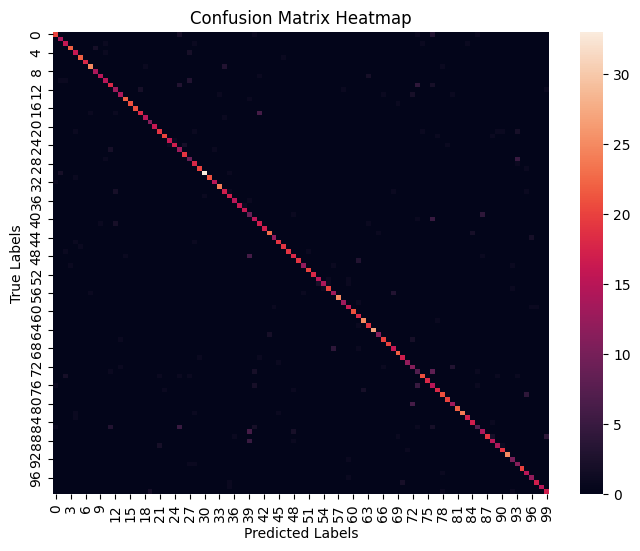

In [125]:
X = selected_users_df.iloc[:, 2:]
y = selected_users_df.iloc[:, 1]
print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
print(X_train.shape, X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifier = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=2)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, fmt='g')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## 5.2 Word2Vec

Accuracy: 80.70%


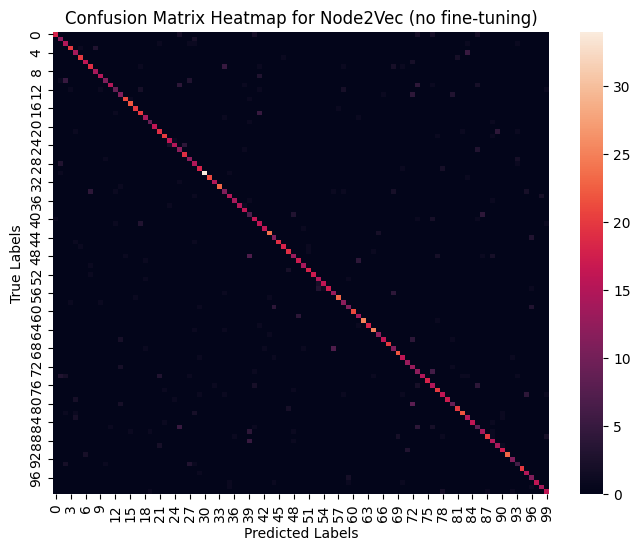

In [126]:
y_true_word2vec = selected_users_test_df['diseases']
y_pred_word2vec = predict_word2vec(word2vec_model.wv, selected_users_test_df, set(selected_users_train_df['user_index']), k=1)

accuracy = accuracy_score(y_true_word2vec, y_pred_word2vec)
print(f'Accuracy: {accuracy * 100:.2f}%')
conf_matrix = confusion_matrix(y_true_word2vec, y_pred_word2vec)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, fmt='g')
plt.title('Confusion Matrix Heatmap for Node2Vec (no fine-tuning)')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [127]:
predicted_10 = predict_word2vec(word2vec_model.wv, selected_users_test_df, set(selected_users_train_df['user_index']), enforce_user=False)
len(predicted_10), len(predicted_10[0])

(2000, 10)

In [128]:
mrr10 = mrr(selected_users_test_df['diseases'], predicted_10)
mrr10
# mrr0

np.float64(0.859454365079365)

# Phase 6. Results

| Model                    | Accuracy@1 | MRR@10 |
|--------------------------|------------|--------|
| Random Forest Classifier |  86.30%    |   -    |
| Node2Vec*                |  80.70%    | 85.94% |

\* Node2Vec can predict nodes outside of the `selected_train_user_df` node id - diseases, drugs, users and phenotypes, even edges.
We only look at the user nodes sampled and ignore the rest. We take the predicted users diseases as the predicted label.
We do this because RFC predicts diseases labels directly, otherwise, the comparison becomes skewed.

If we take the other node types into account, Node2Vec metrics would do: Accuracy fall to ~60% and MRR fall to ~75%.


# Phase 7. Future Work

Mapping the symptoms and diseases of the `Disease-Symptom Dataset` using pure lexical distance metrics was a fast and dirty 'hack'. It is a highly inaccurate technique and needs expert knowledge and consultation for better representation.

The final graph structure H uses only 4/10 types of nodes and 4-5/30 edge types. We had to cut a very big part of the original `PrimeKG` graph for computational reasons. As such H has lost a lot of its reasoning power and context. A bigger and better selected subgraph of `PrimeKG` could improve the metrics.

Feature augmentation of the graph in preparation for training a Graph Neural Networks (or Heterogenous Graph Neural Networks) on the data for better representation than random walks.

The random walks generation could be improved to include more information about the graph and capture better representation of nodes. As well as fine-tuning the `Word2Vec` model with techniques such as `GridSearch` or `RandomSearch`.

# Phase 8. Conclusion

In conclusion, we have made a Medical Recommendation System powered by cut down subgraph of the Prime Knowledge Graph, evaluated with accuracy scores and mean reciprocal rank, enhanced by a local Large Language Model (LLM).

Because user symptoms in our dataset differ from the formalized biomedical ontologies, we utilized lexical distance algorithms (Levenshtein distance and difflib) to construct unified names, linking user symptoms to their respective nodes within the KG.

Due to the massive computational scale of the full PrimeKG graph, we made a subgraph (denoted as H) restricted to 4 core node types and 4–5 specific edge types between them. We simulated random walks across the graph, which were then processed using a Word2Vec model to generate custom node embeddings.

Lastly, we designed a hybrid approach that integrates our graph-based recommendation context system with localized LLMs. This setup makes the language model provide medical context and interpret paths in the knowledge graph structure.

While the compressed subgraph H was successful, its trimmed nature limits its overall reasoning power. Nevertheless, this implementation is a reliable starting template for scalable, explainable, and graph-augmented clinical decision support systems.